In [1]:
from dotenv import load_dotenv
import os
import findspark

load_dotenv()
findspark.init(os.getenv('SPARK_PATH'))

In [2]:
# import findspark
# import os

# # Tự động lấy đường dẫn từ hệ thống, nếu không thấy thì mới báo lỗi
# spark_home = os.environ.get('SPARK_HOME')
# findspark.init(spark_home)

from pyspark.sql import SparkSession
from pyspark.sql.functions import col, avg, desc

# Khởi tạo Spark Session
spark = SparkSession.builder \
    .appName("Spark_Demo_KHTN") \
    .getOrCreate()

print("Spark Session đã sẵn sàng, phiên bản:", spark.version)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/05/18 14:04:48 WARN Utils: Your hostname, THIEN-NHAN-14, resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
26/05/18 14:04:48 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/18 14:04:49 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark Session đã sẵn sàng, phiên bản: 4.1.1


In [3]:
# Tạo danh sách dữ liệu mẫu (Tên, Môn học, Điểm số)
data = [
    ("Thien Nhan", "Data Science", 9.5),
    ("Anh Tri", "Data Science", 8.0),
    ("Ba Dat", "Machine Learning", 9.0),
    ("Dang Khoi", "Machine Learning", 7.5),
    ("Thao My", "Data Science", 10.0),
    ("Nhat Tien", "Machine Learning", 8.5)
]

# Chuyển list thành Spark DataFrame
columns = ["Student", "Subject", "Score"]
df = spark.createDataFrame(data, schema=columns)

# Hiển thị dữ liệu
df.show()

+----------+----------------+-----+
|   Student|         Subject|Score|
+----------+----------------+-----+
|Thien Nhan|    Data Science|  9.5|
|   Anh Tri|    Data Science|  8.0|
|    Ba Dat|Machine Learning|  9.0|
| Dang Khoi|Machine Learning|  7.5|
|   Thao My|    Data Science| 10.0|
| Nhat Tien|Machine Learning|  8.5|
+----------+----------------+-----+



In [4]:
# 1. Lọc sinh viên có điểm > 8.0
# 2. Nhóm theo môn học và tính điểm trung bình
# 3. Sắp xếp theo điểm trung bình giảm dần

analysis_df = df.filter(col("Score") > 8.0) \
                .groupBy("Subject") \
                .agg(avg("Score").alias("Average_Score")) \
                .orderBy(desc("Average_Score"))

# Xuất kết quả
analysis_df.show()

+----------------+-------------+
|         Subject|Average_Score|
+----------------+-------------+
|    Data Science|         9.75|
|Machine Learning|         8.75|
+----------------+-------------+



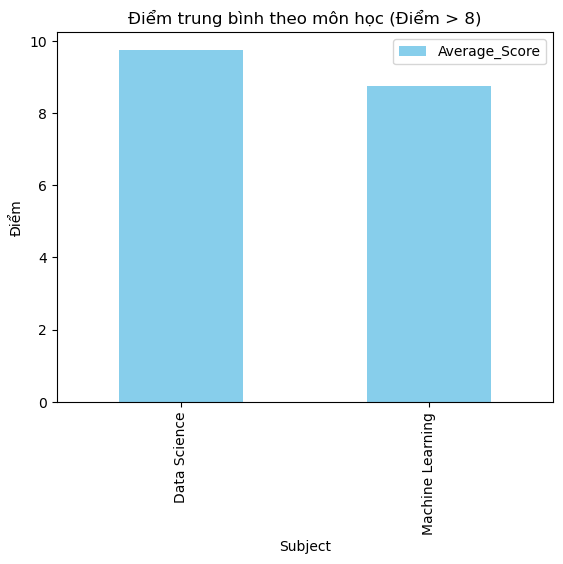

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# Chuyển từ Spark DataFrame sang Pandas DataFrame
pandas_df = analysis_df.toPandas()

# Vẽ biểu đồ đơn giản
pandas_df.plot(kind='bar', x='Subject', y='Average_Score', color='skyblue')
plt.title("Điểm trung bình theo môn học (Điểm > 8)")
plt.ylabel("Điểm")
plt.show()

In [6]:
# Ô cuối cùng của Notebook
# Giải phóng tài nguyên sau khi đã hoàn thành phân tích
spark.stop()
print("Spark Session đã đóng thành công.")

Spark Session đã đóng thành công.
